In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv("../data/base3_phishing_websites/base_phishing_sites.csv")

linhas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas removidas por duplicidade: {linhas_antes - len(df)} (restam {len(df)})")

df["target"] = (df["Result"] == -1).astype(int)
df = df.drop(columns="Result")

Linhas removidas por duplicidade: 5206 (restam 5849)


In [2]:
contagem_classes = df.groupby("target")["target"].count()
total = contagem_classes.sum()
porcentagem_classes = contagem_classes / total * 100
print(porcentagem_classes)

target
0    48.384339
1    51.615661
Name: target, dtype: float64


In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Treinamento:", X_train.shape, " Teste:", X_test.shape)

Treinamento: (4386, 30)  Teste: (1463, 30)


In [4]:
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

colunas_categoricas = X.columns.tolist()
pre_processamento = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas)
])

In [5]:
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("pre", pre_processamento),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

parametros_logreg = {
    "clf__C": [0.01, 0.1, 0.3, 1, 3, 10, 30],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["saga"],
    "clf__l1_ratio": [0.0, 1.0],
}

busca_logreg = RandomizedSearchCV(
    pipe_logreg, parametros_logreg, n_iter=10,
    scoring="f1",
    cv=validacao, random_state=42, n_jobs=-1,
)
busca_logreg.fit(X_train, y_train)

print("Regressão Logística - melhores hiperparâmetros:", busca_logreg.best_params_)
print("Regressão Logística - F1 médio na validação:", round(busca_logreg.best_score_, 4))

Regressão Logística - melhores hiperparâmetros: {'clf__solver': 'saga', 'clf__l1_ratio': 1.0, 'clf__class_weight': None, 'clf__C': 1}
Regressão Logística - F1 médio na validação: 0.9411


In [6]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("pre", pre_processamento),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

parametros_rf = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [None, "balanced"],
    "clf__criterion": ["gini", "entropy"],
    "clf__max_samples": [0.5, 0.7, 0.85, None],
}

busca_rf = RandomizedSearchCV(
    pipe_rf, parametros_rf, n_iter=35,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_rf.fit(X_train, y_train)

print("Random Forest - melhores hiperparâmetros:", busca_rf.best_params_)
print("Random Forest - F1 médio na validação:", round(busca_rf.best_score_, 4))

Random Forest - melhores hiperparâmetros: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_samples': None, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': None}
Random Forest - F1 médio na validação: 0.9497


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline([
    ("pre", pre_processamento),
    ("clf", GradientBoostingClassifier(random_state=42)),
])

parametros_gb = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4],
    "clf__subsample": [0.7, 0.85, 1.0],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", None],
}

busca_gb = RandomizedSearchCV(
    pipe_gb, parametros_gb, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_gb.fit(X_train, y_train)

print("Gradient Boosting - melhores hiperparâmetros:", busca_gb.best_params_)
print("Gradient Boosting - F1 médio na validação:", round(busca_gb.best_score_, 4))

Gradient Boosting - melhores hiperparâmetros: {'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__min_samples_leaf': 4, 'clf__max_features': None, 'clf__max_depth': 3, 'clf__learning_rate': 0.1}
Gradient Boosting - F1 médio na validação: 0.9528


In [8]:
resultados = {
    "Regressão Logística": busca_logreg,
    "Random Forest": busca_rf,
    "Gradient Boosting": busca_gb,
}

for nome, busca in resultados.items():
    print(f"{nome:22s} F1 médio (validação) = {busca.best_score_:.4f}")

melhor_nome = max(resultados, key=lambda k: resultados[k].best_score_)
melhor_modelo = resultados[melhor_nome].best_estimator_
print(f"\nModelo selecionado: {melhor_nome}")

Regressão Logística    F1 médio (validação) = 0.9411
Random Forest          F1 médio (validação) = 0.9497
Gradient Boosting      F1 médio (validação) = 0.9528

Modelo selecionado: Gradient Boosting


Limiar de decisão utilizado nas métricas de classe prevista: 0.5
                     Acurácia  Precisão  Recall  F1-score  AUC-ROC  \
Modelo                                                               
Regressão Logística    0.9323    0.9444  0.9232    0.9337   0.9852   
Random Forest          0.9392    0.9512  0.9298    0.9404   0.9869   
Gradient Boosting      0.9474    0.9593  0.9377    0.9484   0.9907   

                     AUC-PR (trapézio)  Average Precision (AP)  
Modelo                                                          
Regressão Logística             0.9867                  0.9867  
Random Forest                   0.9888                  0.9888  
Gradient Boosting               0.9918                  0.9918  


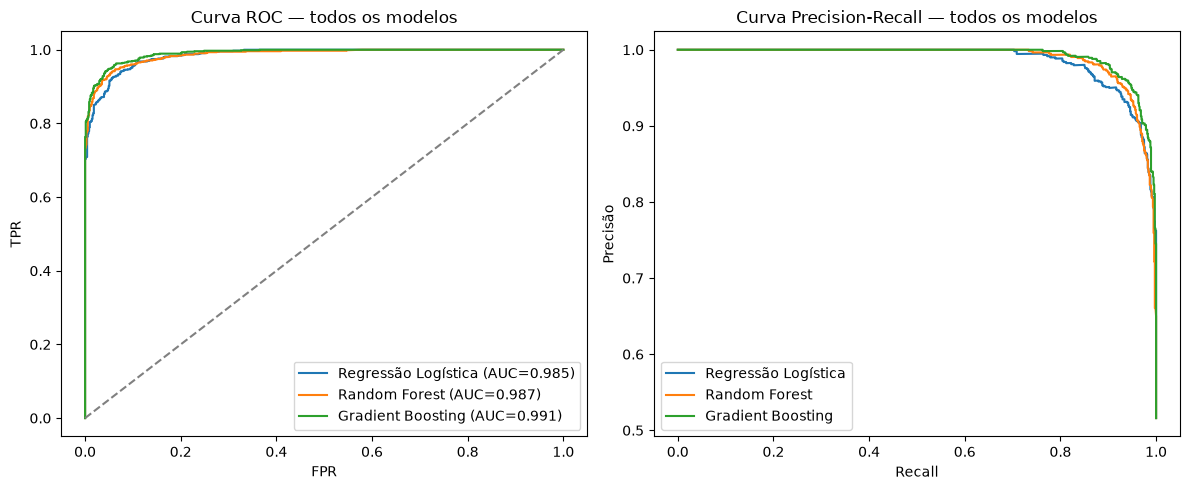

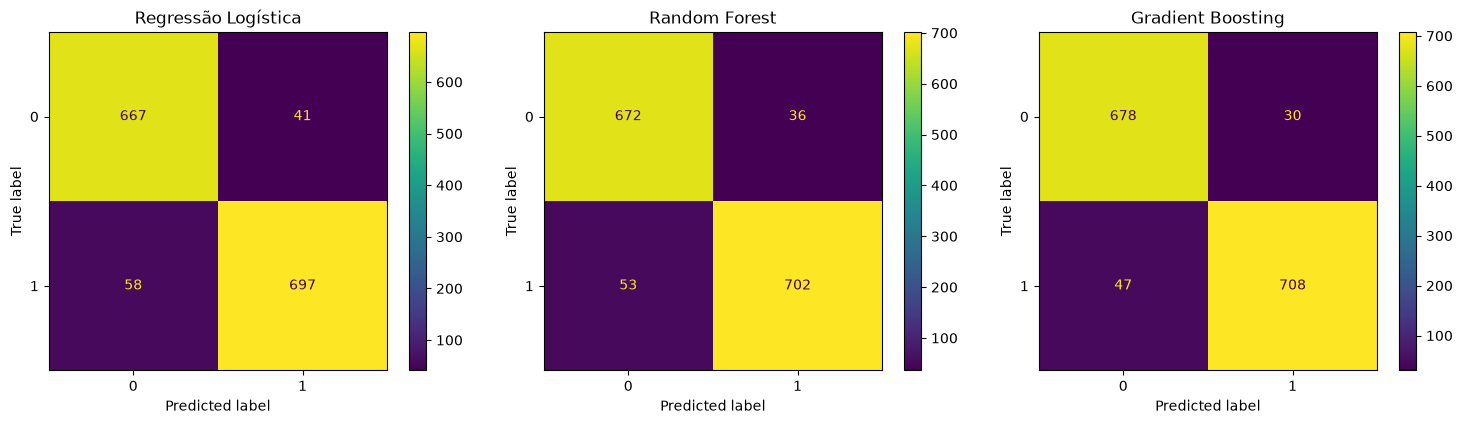

In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import pandas as pd

LIMIAR = 0.5

linhas_metricas = []
curvas = {}

for nome, busca in resultados.items():
    modelo = busca.best_estimator_
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= LIMIAR).astype(int)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precisao_c, recall_c, _ = precision_recall_curve(y_test, y_prob)

    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr = auc(recall_c, precisao_c)
    ap = average_precision_score(y_test, y_prob)

    linhas_metricas.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": auc_roc,
        "AUC-PR (trapézio)": auc_pr,
        "Average Precision (AP)": ap,
    })

    curvas[nome] = dict(fpr=fpr, tpr=tpr, recall=recall_c, precisao=precisao_c,
                         auc_roc=auc_roc, y_pred=y_pred, y_prob=y_prob)

tabela_comparativa = pd.DataFrame(linhas_metricas).set_index("Modelo").round(4)
print(f"Limiar de decisão utilizado nas métricas de classe prevista: {LIMIAR}")
print(tabela_comparativa)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for nome, c in curvas.items():
    eixos[0].plot(c["fpr"], c["tpr"], label=f"{nome} (AUC={c['auc_roc']:.3f})")
    eixos[1].plot(c["recall"], c["precisao"], label=nome)

eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC — todos os modelos")
eixos[0].set_xlabel("FPR"); eixos[0].set_ylabel("TPR"); eixos[0].legend()

eixos[1].set_title("Curva Precision-Recall — todos os modelos")
eixos[1].set_xlabel("Recall"); eixos[1].set_ylabel("Precisão"); eixos[1].legend()

plt.tight_layout()
plt.show()

fig, eixos_cm = plt.subplots(1, len(curvas), figsize=(5 * len(curvas), 4))
for ax, (nome, c) in zip(eixos_cm, curvas.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, c["y_pred"], ax=ax)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

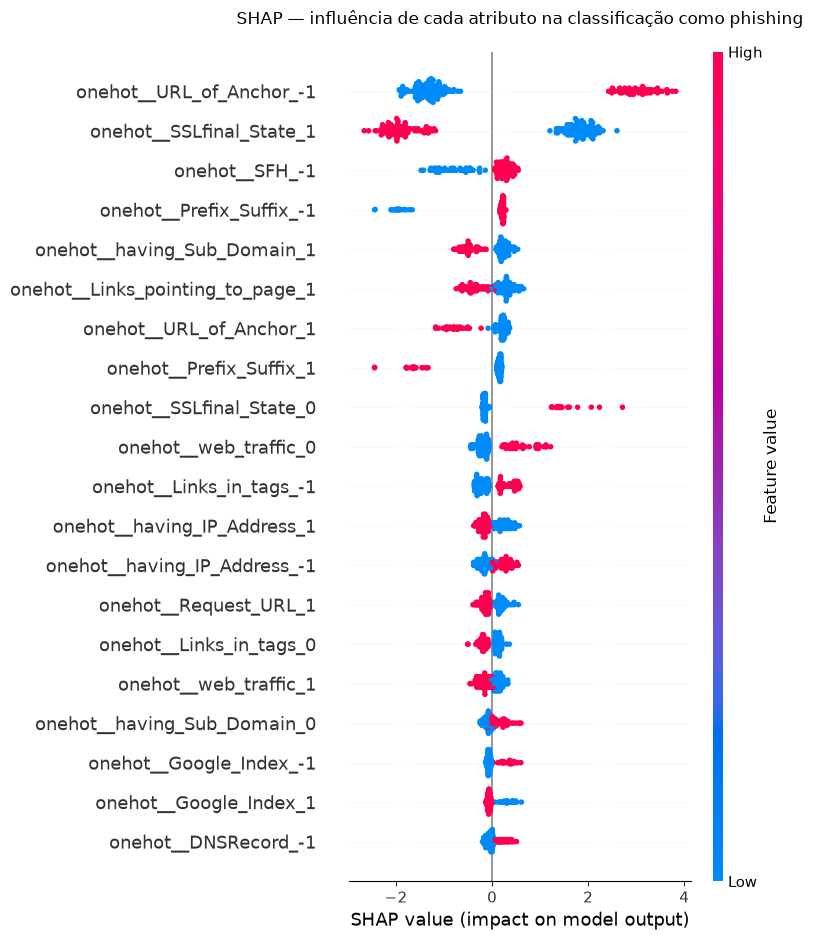

In [10]:
import shap

pre_ajustado = melhor_modelo.named_steps["pre"]
clf_ajustado = melhor_modelo.named_steps["clf"]
nomes_atributos = pre_ajustado.get_feature_names_out()

X_test_codificado = pre_ajustado.transform(X_test)
if hasattr(X_test_codificado, "toarray"):
    X_test_codificado = X_test_codificado.toarray()

rng = np.random.default_rng(42)
quantidade_amostras = min(200, X_test_codificado.shape[0])
indices_shap = rng.choice(X_test_codificado.shape[0], size=quantidade_amostras, replace=False)

X_shap = pd.DataFrame(X_test_codificado[indices_shap], columns=nomes_atributos)

explainer = shap.TreeExplainer(clf_ajustado)
valores_shap = explainer(X_shap)

shap.summary_plot(
    valores_shap.values, X_shap, feature_names=nomes_atributos,
    plot_type="dot", max_display=20, show=False,
)
plt.title("SHAP — influência de cada atributo na classificação como phishing", pad=20)
plt.tight_layout(); plt.show()

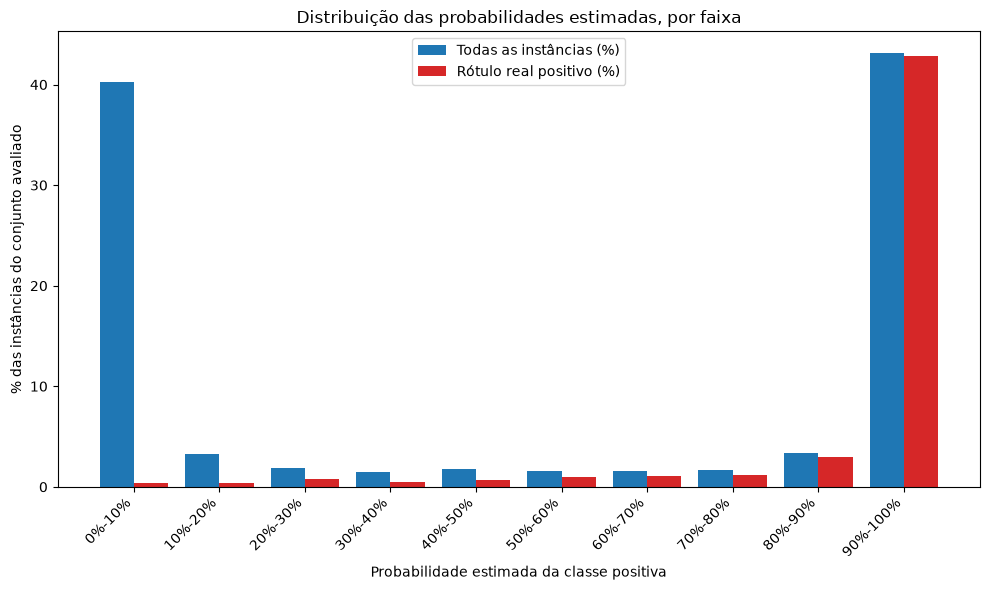

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                 1765                40.241678   
1   10%-20%                  145                 3.305974   
2   20%-30%                   84                 1.915185   
3   30%-40%                   64                 1.459188   
4   40%-50%                   77                 1.755586   
5   50%-60%                   67                 1.527588   
6   60%-70%                   69                 1.573187   
7   70%-80%                   75                 1.709986   
8   80%-90%                  148                 3.374373   
9  90%-100%                 1892                43.137255   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                       17                0.963173  
1                       16               11.034483  
2                       32               38.095238  
3                       19               29.687500  
4                       29               37.662338  
5         

In [11]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import gerar_grafico_e_metricas

proba_oof = cross_val_predict(melhor_modelo, X_train, y_train, cv=validacao, method="predict_proba")[:, 1]

fig, ax, tabela_validacao, _ = gerar_grafico_e_metricas(y_train.values, proba_oof, bin_width=10)
plt.show()
print(tabela_validacao)

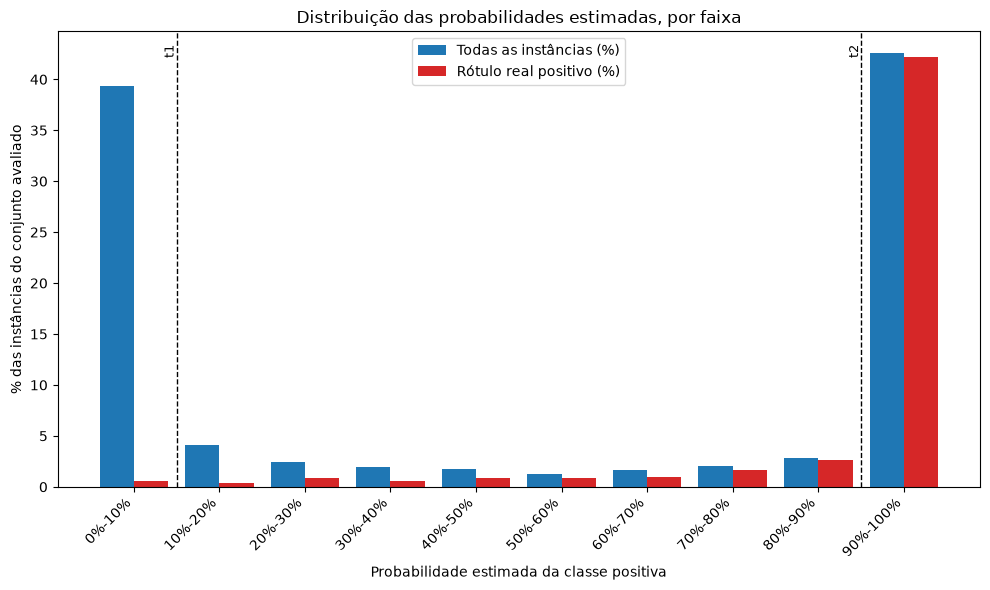

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                  575                39.302802   
1   10%-20%                   60                 4.101162   
2   20%-30%                   36                 2.460697   
3   30%-40%                   29                 1.982228   
4   40%-50%                   25                 1.708817   
5   50%-60%                   19                 1.298701   
6   60%-70%                   24                 1.640465   
7   70%-80%                   30                 2.050581   
8   80%-90%                   42                 2.870813   
9  90%-100%                  623                42.583732   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                        8                1.391304  
1                        6               10.000000  
2                       12               33.333333  
3                        8               27.586207  
4                       13               52.000000  
5         

In [12]:
melhor_modelo.fit(X_train, y_train)
proba_teste = melhor_modelo.predict_proba(X_test)[:, 1]

fig, ax, tabela_teste, metricas = gerar_grafico_e_metricas(
    y_test.values, proba_teste, bin_width=10, t1=10, t2=90
)
plt.show()
print(tabela_teste)
print(metricas)